# **Detecção de forma OpenCV**

As descrições abaixo tem como objetivo reproduzir e estudar a implementação de detecção de formas geométricas apresentada no tutorial: [OpenCV Shape Detection - PyImageSearch](https://pyimagesearch.com/2016/02/08/opencv-shape-detection/).

Além da reprodução da implementação original, foram realizados testes com outra imagem com a finalidade de melhorar a implementação original, e no final foi discutido possíveis aplicações das técnicas utilizadas em outros problemas de visão computacional.

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### **Detecção de formas** 

<div align="center"> detect(c) </div>

Função responsável por analisar um **contorno c** e determinar qual forma geométrica ele representa. 

Resumidamente, a função calcula o perímetro do contorno através do arcLength(), depois simplifica esse contorno utilizando approxPolyDP() e verifica quantos vértices existem nessa aproximação. A partir da quantidade de vértices, ela classifica a forma e retorna seu nome, como "triangle", "square" ou "circle".

---

**Para calcular o perímetro de um contorno, usa-se**:

<div align="center"> cv2.arcLength(c, True) </div>

***curve***: Corresponde ao contorno que se deseja medir;

***closed***: Corresponde a um valor booleano que indica se o contorno deve ser tratado como fechado, ou seja, se o último ponto está conectado ao primeiro.

---

**Para aproximar e simplificar um contorno, usa-se:**

<div align="center"> cv2.approxPolyDP(curve, epsilon, closed) </div>


***curve***: Corresponde ao contorno original;

***epsilon***: Corresponde à tolerância da aproximação: a distância máxima permitida entre o contorno original e a aproximação. No código, é dado por 0.04 * peri, ou seja, 4% do perímetro;

***closed***: Corresponde a um valor booleano que indica se o contorno é fechado.


Um contorno real pode possuir muitos pontos mesmo quando representa uma forma simples; a função tenta representá-lo usando apenas os pontos mais importantes, gerando uma aproximação poligonal. Quanto maior o **epsilon**, maior a diferença tolerada entre o contorno original e a aproximação, e menos pontos são utilizados; quanto menor o epsilon, mais pontos são preservados.


In [29]:
class ShapeDetector:
    def __init__(self):
        pass

    def detect(self, c):
        shape = "unidentified"
        peri = cv2.arcLength(c, True) # Calcula o perímetro do contorno
        approx = cv2.approxPolyDP(c, 0.04 * peri, True) # aproxima e simplifica um contorno

        if len(approx) == 3:
            shape = "triangle"

        elif len(approx) == 4:
            (x, y, w, h) = cv2.boundingRect(approx)

            ar = w/float(h)
            shape = "square" if ar>=0.95 and ar<= 1.05 else "rectangle"

        elif len(approx) == 5:
            shape = "pentagon"

        else:
            shape = "circle"

        return shape




Para encontrar o menor retângulo alinhado aos eixos que envolve um contorno, usa-se:

<div align="center"> x, y, w, h = cv2.boundingRect(array) </div>


***array***: Corresponde ao contorno (ou pontos) a ser envolvido pelo retângulo.


A função retorna quatro valores: x e y, a posição do canto superior esquerdo do retângulo, e w e h, sua largura e altura. 

No tutorial, ela é usada apenas quando o contorno tem quatro vértices, para diferenciar quadrado de retângulo a partir do aspect ratio, ar = w / float(h):
- valores de ar entre 0.95 e 1.05 são classificados como "square"; 
- fora desse intervalo, como "rectangle". 

Essa margem existe porque, em uma imagem real, pequenas distorções podem fazer um quadrado não ter exatamente ar = 1.

### **Pré processamento**

Antes de encontrar os contornos, é necessário realizar um pré-processamento da imagem para facilitar a identificação das formas.

Primeiramente, a imagem é redimensionada utilizando um fator de escala.
No código, dsize é montado a partir de **new_width** e **new_height**, calculados multiplicando a largura e a altura originais pelo fator **scale**, o que preserva a proporção da imagem. 

O fator ratio (inverso de scale) é guardado para reconverter, mais adiante, as coordenadas encontradas na imagem redimensionada de volta para a escala da imagem original.

In [30]:
image = cv2.imread("image/shapes_and_colors.jpg")

scale = 300 / image.shape[1]

new_width = int(image.shape[1] * scale)
new_height = int(image.shape[0] * scale)

resized = cv2.resize(image, (new_width, new_height))
ratio = 1 / scale

Em seguida, a imagem, que está originalmente no formato BGR é convertida para a escala de tons de cinza. 

Depois, é aplicado um desfoque gaussiano utilizando **cv2.GaussianBlur()** para suavizar a imagem e reduzir pequenos ruídos que poderiam interferir na identificação das formas.

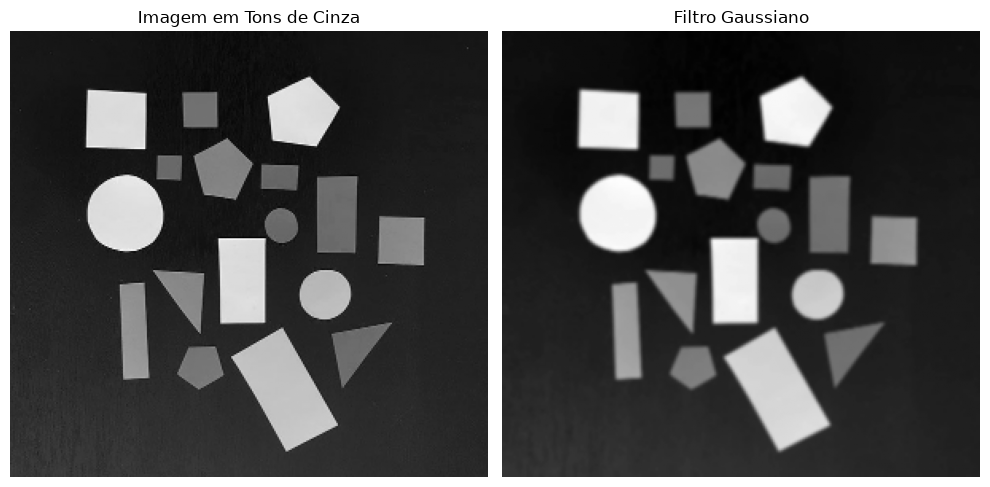

In [47]:
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

gaussian = cv2.GaussianBlur(gray, (5,5),0)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))

ax0.imshow(gray, cmap= 'gray')
ax0.set_title("Imagem em Tons de Cinza")
ax0.axis("off")

ax1.imshow(gaussian, cmap='gray')
ax1.set_title("Filtro Gaussiano")
ax1.axis("off")

plt.tight_layout()

Na sequência, é aplicado um limiar utilizando **cv2.threshold()**. Essa operação transforma a imagem em uma representação binária e dessa forma, as regiões de interesse ficam destacadas, facilitando a identificação das formas.

(np.float64(-0.5), np.float64(299.5), np.float64(279.5), np.float64(-0.5))

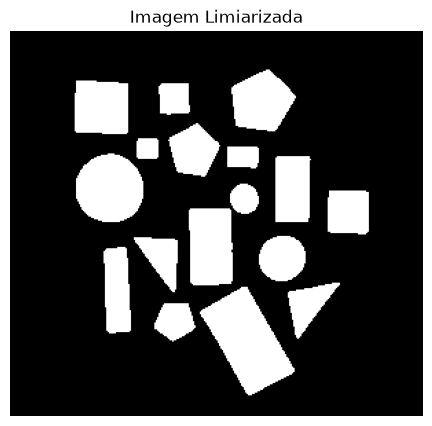

In [43]:
ret, threshold = cv2.threshold(gaussian, 60, 255, cv2.THRESH_BINARY)

fig, (ax0) = plt.subplots(1, 1, figsize=(10, 5))
ax0.imshow(threshold, cmap= 'gray')
ax0.set_title("Imagem Limiarizada")
ax0.axis("off")


### **Encontrando os contornos**

Após esse pré-processamento, é utilizada a função **cv2.findContours()** para encontrar os contornos presentes na imagem binária. Cada contorno representa a borda de uma região identificada na imagem.

**Para encontrar os contornos na imagem binária, usa-se:**

<div align="center"> contours, hierarchy = cv2.findContours(image, mode, method) </div>


***image***: Corresponde à imagem binária de 8 bits;

***mode***: Corresponde ao modo de recuperação dos contornos (aqui, cv2.RETR_EXTERNAL, que retorna apenas os contornos externos);

***method***: Corresponde ao método de aproximação (aqui, cv2.CHAIN_APPROX_SIMPLE, que armazena apenas os pontos extremos dos segmentos retos).


A função retorna contours, a lista de contornos encontrados, e hierarchy, a relação entre eles. 

In [44]:
contornos, _ = cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

Na estrutura for, os contornos encontrados são percorridos individualmente. Para cada contorno, é calculado o centroide da forma e o contorno é encaminhado ao objeto ShapeDetector, que utiliza o método detect() para identificar a forma geométrica.

Como os contornos foram extraídos da imagem redimensionada, as coordenadas do centroide e os pontos do contorno também estão nessa escala. Por isso, é necessário multiplicá-los pelo fator ratio, fazendo com que correspondam novamente às dimensões da imagem original.

**Para calcular os momentos geométricos de um contorno, usa-se:**

<div align="center"> cv2.moments(array) </div>


***array***: Corresponde ao contorno (ou a uma imagem) cujos momentos serão calculados.


A função retorna um dicionário com os momentos calculados. O momento m00 corresponde à área do contorno, enquanto m10 e m01 são usados no cálculo das coordenadas do centroide: cX = m10/m00 e cY = m01/m00. Verifica-se m00 != 0 para evitar divisão por zero em contornos degenerados (sem área).

---

**Para desenhar o contorno na imagem, usa-se:**

<div align="center"> cv2.drawContours(image, contours, contourIdx, color, thickness) </div>


***image***: Corresponde à imagem sobre a qual o contorno será desenhado;

***contours***: Corresponde à lista de contornos. No código, é passada uma lista com um único contorno já reescalado, [c_scaled];

***contourIdx***: Corresponde ao índice do contorno a ser desenhado dentro da lista. O valor -1 desenha todos os contornos da lista;

***color***: Corresponde à cor do contorno, no formato BGR;

***thickness***: Corresponde à espessura do traço, em pixels.


Depois disso é escrito na imagem o nome da forma.


In [45]:
sd = ShapeDetector()

for c in contornos:

    M = cv2.moments(c)

    if M["m00"] != 0:

        # Centro na imagem REDUZIDA
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])

        # Identifica a forma
        shape = sd.detect(c)

        # Converte centro para a imagem ORIGINAL
        cX = int(cX * ratio)
        cY = int(cY * ratio)

        # Escala o contorno para a imagem original
        c_scaled = c.astype("float") * ratio
        c_scaled = c_scaled.astype("int")

        # Desenha contorno
        cv2.drawContours(image, [c_scaled], -1, (0, 255, 0), 2)

        # Escreve o nome no centro
        cv2.putText(image,shape,(cX - 20, cY),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255, 255, 255),2)



(np.float64(-0.5), np.float64(599.5), np.float64(560.5), np.float64(-0.5))

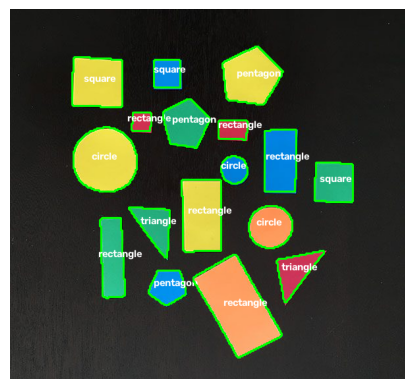

In [35]:
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cv2.imwrite("output/centro.png", rgb)
plt.imshow(rgb)

plt.axis('off')


### **Organizando o código em funções**

In [36]:
def pre_processing(image):

    scale = 300 / image.shape[1]

    new_width = int(image.shape[1] * scale)
    new_height = int(image.shape[0] * scale)

    resized = cv2.resize(image, (new_width, new_height))

    ratio = 1 / scale

    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    gaussian = cv2.GaussianBlur(gray, (5,5), 0)

    ret, threshold = cv2.threshold(gaussian, 60, 255, cv2.THRESH_BINARY)

    return threshold, ratio

def contour(threshold, image, ratio, sd, b, g, r):
    
    contornos, _ = cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for c in contornos:

        M = cv2.moments(c)

        if M["m00"] != 0:

            # Centro na imagem REDUZIDA
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])

            # Identifica a forma
            shape = sd.detect(c)

            # Converte centro para a imagem ORIGINAL
            cX = int(cX * ratio)
            cY = int(cY * ratio)

            # Escala o contorno para a imagem original
            c_scaled = c.astype("float") * ratio
            c_scaled = c_scaled.astype("int")

            # Desenha contorno
            cv2.drawContours(image, [c_scaled], -1, (0, 255, 0), 2)

            # Escreve o nome no centro
            cv2.putText(image,shape,(cX - 20, cY),cv2.FONT_HERSHEY_SIMPLEX,0.5,(b, g, r),2)

    return image


### **Melhorias**

Uma limitação da implementação atual está na classificação das formas com mais de cinco vértices. Como a lógica utilizada considera qualquer forma que não possua 3, 4 ou 5 vértices como um círculo, formas diferentes de um círculo, como hexágonos e figuras irregulares, também acabam sendo classificadas como "circle". Abaixo um exemplo:

(np.float64(-0.5), np.float64(639.5), np.float64(326.5), np.float64(-0.5))

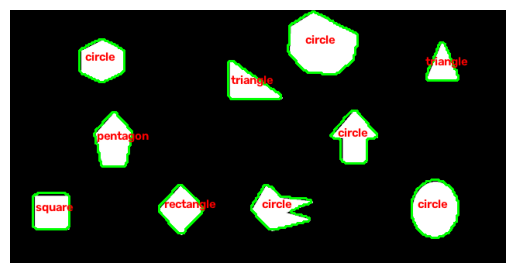

In [37]:
image2 = cv2.imread("image/formatos.png")

sd = ShapeDetector()

threshold, ratio = pre_processing(image2)

contornos2 = contour(threshold,image2,ratio,sd,0, 0, 255)

rgb = cv2.cvtColor(contornos2, cv2.COLOR_BGR2RGB)

cv2.imwrite("output/centro.png", rgb)

plt.imshow(rgb)
plt.axis('off')

Uma alternativa foi separar a identificação do círculo da quantidade de vértices. As formas conhecidas continuaram sendo classificadas pelo número de vértices. 

Porém, para as formas com mais de cinco vértices, em vez de assumir que se trata de um círculo, o algoritmo utiliza uma característica geométrica específica, como a **circularidade**, para verificar o quanto o contorno se aproxima de um círculo.

Caso a forma apresente características compatíveis com um círculo, ela será classificada como "circle". Caso contrário, poderá ser classificada genericamente como "other".

In [38]:
#circularity = (4 * np.pi * area) / (peri ** 2)

A tentativa de incluir a identificação de círculos na implementação não deu muito certo.

Como a lógica inicial do ShapeDetector é baseada principalmente na quantidade de vértices obtidos pelo approxPolyDP(), utilizar um único valor global de epsilon acabou gerando classificações incorretas. 

O mesmo contorno poderia ser aproximado com diferentes quantidades de vértices dependendo da sua geometria, fazendo com que círculos fossem interpretados como hexágonos ou outras formas também apresentassem seis vértices. Por isso, apenas aumentar ou diminuir o epsilon global não foi uma solução adequada.

Dessa forma, mantive o valor global, a circularidade, e outra característica geométrica foi adicionada: a proporção entre o menor e o maior lado.

**is_hexagon(approx)** é uma função auxiliar criada para diferenciar um hexágono de outras formas que também podem ser aproximadas por seis vértices. Ela recebe os seis pontos de approx, calcula o comprimento de cada lado e verifica se esses lados possuem tamanhos semelhantes.

ratio = min(sides) / max(sides): compara o menor lado com o maior. Se os lados forem semelhantes, o resultado será próximo de 1; se forem muito diferentes, será menor.

return ratio > 0.7: define que a forma será considerada um hexágono quando o menor lado tiver pelo menos 70% do tamanho do maior. Assim, o algoritmo não considera apenas os seis vértices, mas também verifica se a distribuição dos lados é compatível com um hexágono.


In [39]:
def is_hexagon(approx):

    sides = []

    for i in range(6):
        p1 = approx[i][0]
        p2 = approx[(i + 1) % 6][0]

        distance = np.linalg.norm(p2 - p1)
        sides.append(distance)

    ratio = min(sides) / max(sides)

    return ratio > 0.7



Para calcular a área delimitada por um contorno, usa-se:

<div align="center"> cv2.contourArea(contour) </div>


***contour***: Corresponde ao contorno cuja área será calculada.


É utilizada, junto do perímetro (peri), para calcular a circularidade da forma: circularity = (4 * np.pi * area) / (peri ** 2). Esse valor é 1 para um círculo perfeito e se afasta de 1 conforme a forma se torna menos circular.

Para verificar se um contorno é convexo, usa-se:

<div align="center"> cv2.isContourConvex(contour) </div>


***contour***: Corresponde ao contorno (já aproximado por approxPolyDP) a ser verificado.


A função retorna True se o contorno for convexo (nenhum de seus ângulos internos é reflexo) e False caso contrário. No código, ela é usada para descartar como hexágono qualquer forma de seis vértices que seja côncava.



In [40]:
class ShapeDetector:
    def __init__(self):
        pass

    def detect(self, c):
        shape = "unidentified"
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.04 * peri, True)

        if len(approx) == 3:
            shape = "triangle"

        elif len(approx) == 4:
            (x, y, w, h) = cv2.boundingRect(approx)

            ar = w/float(h)
            shape = "square" if ar>=0.95 and ar<= 1.05 else "rectangle"

        elif len(approx) == 5:
            shape = "pentagon"

        elif len(approx) == 6:

            area = cv2.contourArea(c)
            circularity = (4 * np.pi * area) / (peri ** 2)

            if not cv2.isContourConvex(approx):
                shape = "other"

            elif circularity > 0.88:
                shape = "circle"

            elif is_hexagon(approx):
                shape = "hexagon"

            else:
                shape = "other"
        else:

            area = cv2.contourArea(c)
            circularity = (4 * np.pi * area) / (peri ** 2)

            if circularity > 0.85:
                shape = "circle"
            else:
                shape = "other"
        return shape



In [41]:
def pre_processing(image):

    scale = 300 / image.shape[1]

    new_width = int(image.shape[1] * scale)
    new_height = int(image.shape[0] * scale)

    resized = cv2.resize(image, (new_width, new_height))

    ratio = 1 / scale

    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    gaussian = cv2.GaussianBlur(gray, (5,5), 0)

    ret, threshold = cv2.threshold(gaussian, 60, 255, cv2.THRESH_BINARY)

    return threshold, ratio

def contour(threshold, image, ratio, sd, b, g, r):
    
    contornos, _ = cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for c in contornos:

        M = cv2.moments(c)

        if M["m00"] != 0:

            # Centro na imagem REDUZIDA
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])

            # Identifica a forma
            shape = sd.detect(c)

            # Converte centro para a imagem ORIGINAL
            cX = int(cX * ratio)
            cY = int(cY * ratio)

            # Escala o contorno para a imagem original
            c_scaled = c.astype("float") * ratio
            c_scaled = c_scaled.astype("int")

            # Desenha contorno
            cv2.drawContours(image, [c_scaled], -1, (0, 255, 0), 2)

            # Escreve o nome no centro
            cv2.putText(image,shape,(cX - 20, cY),cv2.FONT_HERSHEY_SIMPLEX,0.5,(b, g, r),2)

    return image


(np.float64(-0.5), np.float64(639.5), np.float64(326.5), np.float64(-0.5))

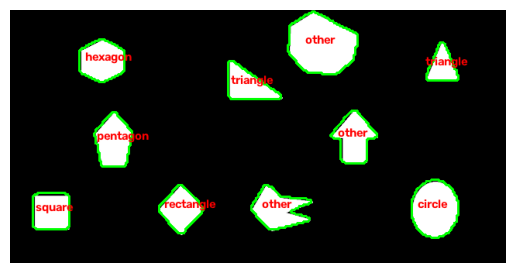

In [42]:
image2 = cv2.imread("image/formatos.png")

sd = ShapeDetector()

threshold, ratio = pre_processing(image2)

contornos2 = contour(threshold,image2,ratio,sd,0, 0, 255)

rgb = cv2.cvtColor(contornos2, cv2.COLOR_BGR2RGB)

cv2.imwrite("output/centro.png", rgb)

plt.imshow(rgb)
plt.axis('off')

Apesar da melhoria na classificação, a solução ainda depende dos parâmetros utilizados na aproximação dos contornos e dos limiares definidos durante o pré-processamento.

Alterações na iluminação, ruído, escala ou geometria das formas podem alterar a quantidade de vértices obtidos por **approxPolyDP()**, afetando a classificação.

### **Aplicações**

A técnica de detecção de formas pode ser aplicada em sistemas de inspeção visual industrial, nos quais características geométricas dos componentes são utilizadas para verificar sua presença, posição ou conformidade.

Um exemplo seria a inspeção de tampas, lacres e componentes circulares. Nesse cenário, as etapas de pré-processamento, detecção de contornos, aproximação poligonal (approxPolyDP), cálculo de área, perímetro e circularidade podem ser utilizadas para localizar e caracterizar o componente. A partir dessas informações, seria possível verificar se o componente está presente, se possui formato esperado ou se apresenta alterações geométricas.